# Week 6 Assignment: Denoising Autoencoder using MNIST

### MCA – Celebal Technologies Internship

## Objective
The objective of this assignment is to build a Convolutional Denoising Autoencoder that learns to reconstruct clean MNIST handwritten digit images from artificially corrupted noisy images.

# 1. Import Required Libraries



This cell imports all the required Python libraries used throughout the project. These libraries help perform image processing, data manipulation, visualization, deep learning model development, and performance evaluation.

In [1]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error

# 2. Check TensorFlow Version



This cell checks the installed TensorFlow version in the current environment. Verifying the version ensures compatibility with the APIs and functions used while building the Convolutional Denoising Autoencoder.

In [2]:
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


# 3. Extract Dataset Files



This cell extracts the compressed MNIST dataset (`archive.zip`) into the working directory. After extraction, the training and testing folders become available for loading the images.

In [3]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# 4. Verify Dataset Structure



This cell verifies that the dataset has been extracted successfully by displaying the folders present inside the dataset directory. The expected folders are **training** and **testing**.

In [4]:
base_path = "/content/mnist_png"

print("Folders inside dataset:")
print(os.listdir(base_path))

Folders inside dataset:
['testing', 'training']


# 5. Count Training and Testing Images


This cell counts the total number of images available in both the training and testing datasets. This helps verify that all images have been extracted correctly before preprocessing.

In [6]:
train_path = "/content/mnist_png/training"
test_path = "/content/mnist_png/testing"

train_count = 0
test_count = 0

for digit in os.listdir(train_path):
    train_count += len(os.listdir(os.path.join(train_path, digit)))

for digit in os.listdir(test_path):
    test_count += len(os.listdir(os.path.join(test_path, digit)))

print(f"Training Images : {train_count}")
print(f"Testing Images  : {test_count}")

Training Images : 60000
Testing Images  : 10000


# 6. Define Image Loading Function



This cell defines a reusable function to load images from the dataset folders. Each image is converted to grayscale, resized if necessary, normalized to pixel values between 0 and 1, and stored as a NumPy array for model training.

In [7]:
def load_images(folder_path):
    images = []

    for label in sorted(os.listdir(folder_path)):
        label_path = os.path.join(folder_path, label)

        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)

            img = Image.open(img_path).convert("L")   # Grayscale
            img = np.array(img, dtype=np.float32) / 255.0   # Normalize

            images.append(img)

    return np.array(images)

# 7. Load Training and Testing Images



This cell loads all the images from the training and testing directories using the previously defined function. The loaded images are stored as NumPy arrays and will be used throughout the remaining steps of the project.

In [8]:
x_train = load_images("/content/mnist_png/training")
x_test = load_images("/content/mnist_png/testing")

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (60000, 28, 28)
Testing Shape  : (10000, 28, 28)


# 8. Reshape Images for CNN Input



Convolutional Neural Networks expect images to have a channel dimension. Since MNIST images are grayscale, this cell adds one channel to every image, converting the shape from (28, 28) to (28, 28, 1).

In [9]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


# 9. Display Sample Original Images


This cell displays a few original handwritten digit images from the training dataset. Visualizing the images helps verify that the dataset has been loaded and preprocessed correctly before adding noise.

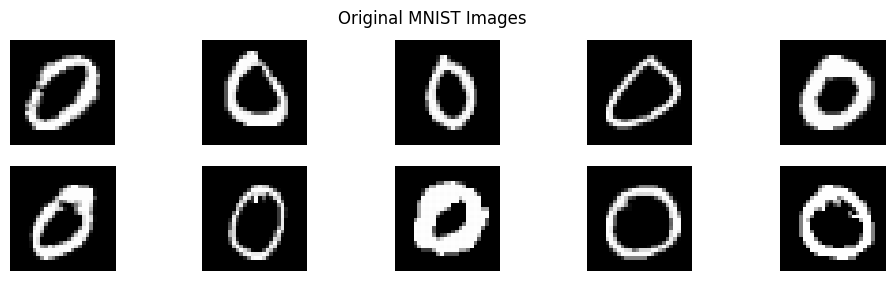

In [10]:
plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original MNIST Images")
plt.show()

# 10. Add Gaussian Noise to Images



To train the denoising autoencoder, Gaussian noise is added to the original images. The noisy images serve as input to the model, while the original clean images are used as the target output during training.

In [11]:
# Noise factor
noise_factor = 0.4

# Generate noisy training images
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Generate noisy testing images
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully!")

Noise added successfully!


# 11. Compare Original and Noisy Images



This cell compares the original handwritten digit images with their noisy versions. The comparison helps visualize the effect of Gaussian noise before the denoising process begins.

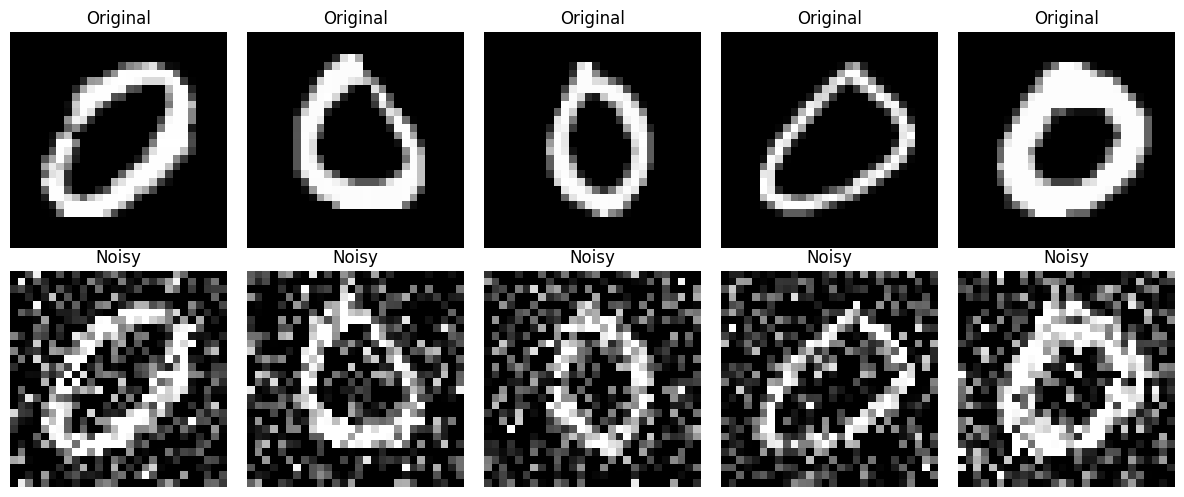

In [12]:
plt.figure(figsize=(12, 5))

for i in range(5):

    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 12. Build the Convolutional Denoising Autoencoder



This cell defines the architecture of the Convolutional Denoising Autoencoder. The encoder extracts important features from the noisy images by reducing their spatial dimensions, while the decoder reconstructs clean images from these learned representations. The final output has the same dimensions as the original input image.

In [13]:
# Input Layer
input_img = Input(shape=(28, 28, 1))


# Encoder


x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)


# Bottleneck


x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)


# Decoder


x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)


autoencoder = Model(input_img, decoded)

# 13. Display Model Architecture



This cell displays the architecture of the Convolutional Denoising Autoencoder. The model summary provides information about each layer, output shape, and the total number of trainable parameters.

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,425 (435.25 KB)

 Trainable params: 111,425 (435.25 KB)

 Non-trainable params: 0 (0.00 B)

# 14. Compile the Autoencoder Model



This cell configures the autoencoder for training by specifying the optimizer and loss function. The Adam optimizer is used for efficient weight updates, while Mean Squared Error (MSE) measures the reconstruction error between the original and denoised images.

In [15]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


# 15. Configure Early Stopping



This cell defines the EarlyStopping callback, which monitors the validation loss during training. If the validation loss does not improve for three consecutive epochs, training stops automatically and restores the best-performing model weights.

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 16. Train the Autoencoder



This cell trains the denoising autoencoder using noisy images as input and the original clean images as the target output. A portion of the training data is reserved for validation to monitor the model's performance during training.

In [17]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 377s 883ms/step - loss: 0.1357 - val_loss: 0.0983
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 376s 872ms/step - loss: 0.0939 - val_loss: 0.0917
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 363s 862ms/step - loss: 0.0905 - val_loss: 0.0891
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 359s 851ms/step - loss: 0.0887 - val_loss: 0.0879
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 370s 822ms/step - loss: 0.0875 - val_loss: 0.0870
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 361s 855ms/step - loss: 0.0866 - val_loss: 0.0864
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 386s 864ms/step - loss: 0.0859 - val_loss: 0.0856
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 381s 863ms/step - loss: 0.0853 - val_loss: 0.0853
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 377s 850ms/step - loss: 0.0848 - val_loss: 0.0846
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 354s 838ms/step - loss: 0.0844 - val_loss: 0.0845
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 401s 951ms/step - loss: 0.0840 - val_loss: 0.0842
Epoch 12

# 17. Plot Training and Validation Loss



This cell visualizes the training and validation loss over multiple epochs. The loss curves help evaluate the learning progress of the model and indicate whether the model is underfitting or overfitting.

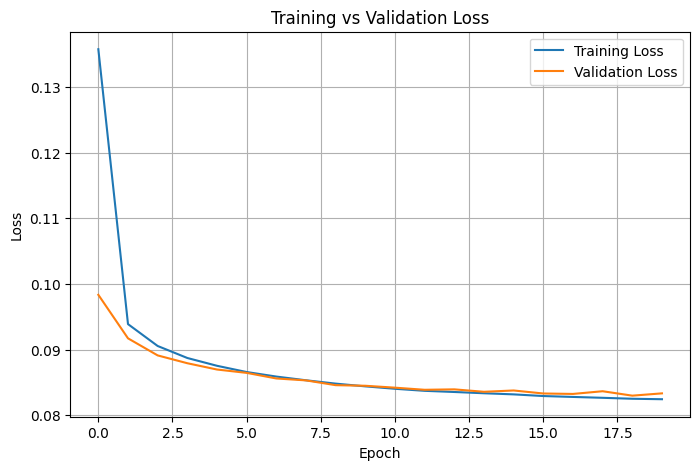

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# 18. Generate Denoised Images



This cell uses the trained autoencoder to reconstruct clean images from the noisy test dataset. The generated output will later be compared with the original and noisy images to evaluate the denoising performance.

In [19]:
denoised_images = autoencoder.predict(x_test_noisy)

print("Prediction Completed!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step
Prediction Completed!


# 19. Visualize Original, Noisy, and Denoised Images



This cell displays the original, noisy, and reconstructed images side by side. The visual comparison demonstrates how effectively the Convolutional Denoising Autoencoder removes Gaussian noise and restores the handwritten digits.

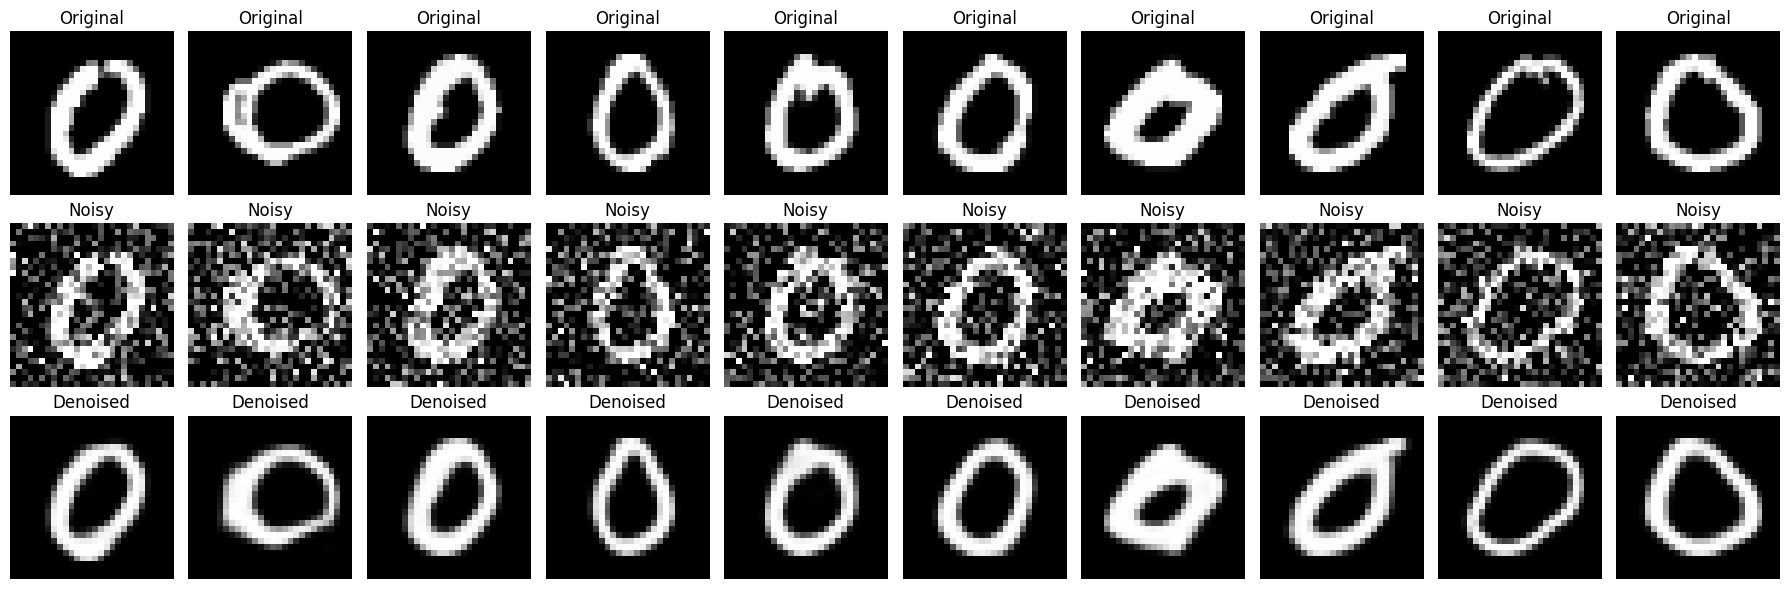

In [20]:
n = 10

plt.figure(figsize=(18,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 20. Evaluate Reconstruction Using Mean Squared Error (MSE)


This cell evaluates the reconstruction quality of the trained autoencoder using Mean Squared Error (MSE). A lower MSE value indicates that the reconstructed images are closer to the original clean images, demonstrating better denoising performance.

In [21]:
mse = np.mean((x_test - denoised_images) ** 2)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.00687882


# Observations

- The MNIST images were successfully loaded, normalized, and converted into the required format.

- Artificial Gaussian noise was added to create noisy input images while preserving the clean images as targets.

- A Convolutional Denoising Autoencoder consisting of an encoder, bottleneck, and decoder was trained to reconstruct clean handwritten digits.

- The training and validation losses decreased steadily, indicating that the model learned meaningful image representations without significant overfitting.

- The reconstructed images were significantly cleaner than the noisy inputs while preserving the overall digit shapes.

- The calculated Mean Squared Error (MSE) was low, demonstrating effective reconstruction performance.

- Very heavily corrupted images occasionally appeared slightly blurred after reconstruction because the model prioritizes removing noise over preserving every fine detail.

# Conclusion

A Convolutional Denoising Autoencoder was successfully implemented using the MNIST dataset. Gaussian noise was artificially added to the input images, and the model learned to reconstruct clean handwritten digits from noisy inputs.

The encoder extracted meaningful features while the decoder reconstructed the original images effectively. Visual comparisons and MSE demonstrated that the model performed well in removing noise while preserving digit structures.

This experiment highlights the effectiveness of convolutional autoencoders for image denoising and demonstrates their potential application in image restoration tasks.